In [1]:
import edn_popdyn.paths
from edn_popdyn.paths import (
    DATA_ROOT, POP_MAT_ROOT, PCA_ROOT, FIGURES_DIR,
)

In [2]:
from edn_popdyn import colors as pal

# 2.2 — Population and single-neuron cosine similarity

Compute population (PCA-trajectory) and single-neuron cosine similarity across strength conditions and test both with one subject-aware mixed model.

In [3]:
import types, sys
import pandas as pd

import re
from collections import defaultdict
from joblib import Parallel, delayed

_numeric_mod = types.ModuleType("pandas.core.indexes.numeric")
_numeric_mod.Int64Index = pd.Index
_numeric_mod.Float64Index = pd.Index
_numeric_mod.UInt64Index = pd.Index
sys.modules["pandas.core.indexes.numeric"] = _numeric_mod

In [4]:
import sys, importlib, importlib.abc, importlib.machinery

class _NumpyCoreRedirect(importlib.abc.MetaPathFinder, importlib.abc.Loader):
    PREFIX = "numpy._core"

    def find_spec(self, fullname, path=None, target=None):
        if fullname == self.PREFIX or fullname.startswith(self.PREFIX + "."):
            return importlib.machinery.ModuleSpec(fullname, self)
        return None

    def create_module(self, spec):
        mod = importlib.import_module("numpy.core" + spec.name[len(self.PREFIX):])
        sys.modules[spec.name] = mod
        return mod

    def exec_module(self, module):
        pass

try:
    import numpy._core
    print("numpy._core present; no shim needed (numpy %s)" % __import__("numpy").__version__)
except ModuleNotFoundError:
    if not any(isinstance(f, _NumpyCoreRedirect) for f in sys.meta_path):
        sys.meta_path.insert(0, _NumpyCoreRedirect())
    import numpy.core
    print("Installed numpy._core -> numpy.core redirect (numpy %s)"
          % __import__("numpy").__version__)

numpy._core present; no shim needed (numpy 1.26.4)


## 0) Imports and configuration

In [5]:
import glob
import itertools
import joblib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import re
import re as _re
import seaborn as sns
import statsmodels.formula.api as smf
import sys
import types
import warnings
import zipfile

from collections import defaultdict
from functools import reduce
from joblib import Parallel, delayed
from pathlib import Path
from pathlib import Path as _P
from scipy import stats
from scipy.stats import ttest_1samp
from scipy.stats import ttest_1samp, wilcoxon
from scipy.stats import ttest_rel, ttest_1samp, wilcoxon, mannwhitneyu
from tqdm.autonotebook import tqdm

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   
warnings.filterwarnings("ignore", category=RuntimeWarning) 

/tmp/ipykernel_768433/2537116594.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [6]:
AREA     = 'ALL'

PCA_BASE_TEMPLATE = str(PCA_ROOT)

OUT_DIR = f"{FIGURES_DIR}"
os.makedirs(OUT_DIR, exist_ok=True)

STRENGTHS   = ("sL", "wL", "wR", "sR")
ACTIVE_ONLY = False
nbins       = 60

COLOR_NEG = pal.delta_neg
COLOR_POS = pal.delta_pos
COLOR_NS  = pal.delta_ns
SIG_ALPHA = 0.05

In [7]:
DOT       = 45
VALID_C   = pal.valid
INVALID_C = pal.invalid_accent

def _bird_means(df):
    return (df.dropna(subset=["session_valid_mean", "session_invalid_mean"])
              .groupby("bird")[["session_valid_mean", "session_invalid_mean"]].mean()
              .rename(columns={"session_valid_mean": "valid", "session_invalid_mean": "invalid"}))

def _sig_color(r):
    if r is None or not r.get("estimable") or not np.isfinite(r.get("p", np.nan)) or r["p"] >= SIG_ALPHA:
        return COLOR_NS
    return COLOR_POS if r["beta"] > 0 else COLOR_NEG

def _ptext(r):
    if r is None: return "n/a"
    if not r.get("estimable"): return "n=%d birds (n.t.)" % r["n_birds"]
    return "LME P=%.2g" % r["p"]

def _sub(df, reg):
    return df.copy() if reg == "ALL" else df[df["region"] == reg].copy()

In [8]:
_SITE_ROWS = [

    ("B1170", 2190, 1660,  900,   0, "right", "Field L", "2021-04-14", "2021-04-29"),
    ("B1170", 1260, 1070,  800,   0, "left",  "NCM",     "2021-04-08", "2021-04-12"),
    ("B1170", 1260, 1070, 1364,   0, "left",  "NCM",     "2021-04-12", "2021-04-13"),
    ("B1188", 2500,  900, 2250,   0, "right", "CMM",     "2020-11-02", "2020-11-20"),
    ("B1244", 2000, 1790, 2000, -30, "left",  "Field L", "2021-05-08", "2021-05-11"),
    ("B1248", 1770, 1000,  800,  90, "left",  "NCM",     "2021-07-09", "2021-08-13"),
    ("B1248", 1770, 1000, 1700,  90, "left",  "NCM",     "2021-08-26", "2021-09-17"),
    ("B1248",  670, 1490,  900, -30, "left",  "NCM",     "2021-07-02", "2021-07-07"),
    ("B1248", 1770, 1000, 2500,  90, "left",  "NCM",     "2021-09-17", "2021-09-28"),
    ("B1276", 2000, 1000, 2250,   0, "right", "CMM",     "2021-03-11", "2021-03-15"),
    ("B1426", 2100,  960, 2000,   0, "right", "CMM",     "2021-02-01", "2021-02-04"),
    ("B1432", 2500,  800, 2000,   0, "right", "CMM",     "2021-02-25", "2021-03-27"),
    ("B1593", 1100, 2200,  950,   0, "left",  "NCM",     "2021-06-16", "2021-08-20"),
    ("B1593", 1100, 2200, 1650,   0, "left",  "NCM",     "2021-08-20", "2021-09-19"),
    ("B1595", 1300, 1000,  900,   0, "right", "NCM",     "2021-03-31", "2021-04-03"),
    ("B1595", 1170, 1680, 1000,   0, "left",  "NCM",     "2021-04-07", "2021-04-09"),
    ("B1595", 1300, 1000, 1490,   0, "right", "NCM",     "2021-04-03", "2021-04-04"),
]
SITE_DF = pd.DataFrame(_SITE_ROWS, columns=["bird", "AP", "ML", "Depth", "Rotation",
                                            "Hemisphere", "region", "start", "end"])
SITE_DF["start"] = pd.to_datetime(SITE_DF["start"])
SITE_DF["end"]   = pd.to_datetime(SITE_DF["end"])
SITE_DF["site_id"] = (SITE_DF["bird"] + "|AP" + SITE_DF["AP"].astype(str)
                      + "|ML" + SITE_DF["ML"].astype(str) + "|D" + SITE_DF["Depth"].astype(str)
                      + "|R" + SITE_DF["Rotation"].astype(str) + "|" + SITE_DF["Hemisphere"])

_date_re = _re.compile(r"(\d{4})[-_](\d{2})[-_](\d{2})")

def _session_bird(s):
    return str(s).split("/")[0].split("_")[0]

def _session_date(s):
    m = _date_re.search(str(s))
    return pd.Timestamp("%s-%s-%s" % m.groups()) if m else pd.NaT

def session_bird_ts(s):

    s = str(s); bird = _session_bird(s)
    m = _re.search(r"dat([0-9].*)$", s)
    if m:
        ts = m.group(1)
    elif "_" in s and "/" not in s:
        ts = s.split("_", 1)[1]
    else:
        ts = None
    return bird, ts

def session_site_region(session):

    bird = _session_bird(session); date = _session_date(session)
    rows = SITE_DF[SITE_DF["bird"] == bird]
    if rows.empty:
        return ("NO_SITE", "unknown")
    if len(rows) == 1:
        r = rows.iloc[0]; return (r.site_id, r.region)
    if pd.isna(date):
        return ("UNDATED", "unknown")
    hit = rows[(rows["start"] <= date) & (date <= rows["end"])]
    if len(hit) >= 1:
        r = hit.sort_values("start").iloc[-1]; return (r.site_id, r.region)
    mids = rows["start"] + (rows["end"] - rows["start"]) / 2
    r = rows.iloc[int(np.argmin(np.abs((mids - date).dt.total_seconds())))]
    return (r.site_id, r.region)

def add_site_region(df, session_col="session"):
    if df.empty:
        return df
    df = df.copy()
    sr = list(df[session_col].map(session_site_region))
    df["site_id"] = [a for a, _ in sr]
    df["region"]  = [b for _, b in sr]
    if "bird" not in df.columns:
        df["bird"] = df[session_col].map(_session_bird)
    return df


print("SITE_DF: %d penetration sites across %d birds; regions=%s"
      % (len(SITE_DF), SITE_DF["bird"].nunique(), sorted(SITE_DF["region"].unique())))

SITE_DF: 17 penetration sites across 9 birds; regions=['CMM', 'Field L', 'NCM']


## 1) Inclusion

In [9]:
def discover_pca_sessions(area):

    pca_base  = PCA_BASE_TEMPLATE.format(area=area)
    pca_paths = sorted(glob.glob(os.path.join(pca_base, '*', '*', 'trial_type_dict_pca.pkl')))
    sessions  = []
    for path in pca_paths:
        rec_dir   = os.path.dirname(path)
        bird      = os.path.basename(os.path.dirname(rec_dir))
        rec       = os.path.basename(rec_dir)
        timestamp = rec.split('dat', 1)[1] if 'dat' in rec else rec
        sessions.append((bird, timestamp))
    print(f"Found {len(sessions)} PCA sessions for area={area!r}")
    return sessions

In [10]:
pca_sessions = discover_pca_sessions(AREA)
birds = [(bird, timestamp, 'kilosort2_5') for bird, timestamp in pca_sessions]
print(f"Using {len(birds)} sessions (from PCA directory for {AREA})")


Found 344 PCA sessions for area='ALL'
Using 344 sessions (from PCA directory for ALL)


In [11]:
_disc_birds = sorted({b for b, _, _ in birds})
print(f"AREA={AREA!r}: discovered {len(birds)} sessions across "
      f"{len(_disc_birds)} birds -> {_disc_birds}")

AREA='ALL': discovered 344 sessions across 9 birds -> ['B1170', 'B1188', 'B1244', 'B1248', 'B1276', 'B1426', 'B1432', 'B1593', 'B1595']


In [12]:
INC_CSV = f"{DATA_ROOT}/included_sessions.csv"
_inc = pd.read_csv(INC_CSV, dtype={"timestamp": str})
INCLUDED_BIRDS_SET = set(_inc["bird"].unique())
_n_before = len(birds)
birds = [(r.bird, r.timestamp, "kilosort2_5") for r in _inc.itertuples()]
print("inclusion list: %d sessions, %d birds, %d sites -> %s"
      % (len(birds), _inc["bird"].nunique(), _inc["site_id"].nunique(),
         sorted(INCLUDED_BIRDS_SET)))
print("`birds` overridden (%d -> %d) for population + single-neuron." % (_n_before, len(birds)))

inclusion list: 250 sessions, 9 birds, 15 sites -> ['B1170', 'B1188', 'B1244', 'B1248', 'B1276', 'B1426', 'B1432', 'B1593', 'B1595']
`birds` overridden (344 -> 250) for population + single-neuron.


In [13]:
EPS_COS, MODALITY_KEEP = 1e-12, "active"
MIN_POP, MIN_SN, SPLITHALF_REPS = 4, 2, 25
STRENGTHS = ("sL", "wL", "wR", "sR")
_VALIDITY_TOKENS = {"NC", "valid", "invalid"}

def _cap():
    return globals().get("NBINS") or 10**9

def parse_key(key):
    t = str(key).split("_")
    if len(t) < 4 or t[0] not in STRENGTHS:
        return None
    vi = next((i for i, x in enumerate(t) if x in _VALIDITY_TOKENS), None)
    if vi is None or vi < 2:
        return None
    return dict(strength=t[0], continuum="_".join(t[1:vi]), validity=t[vi],
                modality=t[-1].lower(), stratum=(t[0], "_".join(t[1:vi])))

def _cos(a, b, eps=EPS_COS):
    a = np.asarray(a, float).ravel(); b = np.asarray(b, float).ravel()
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < eps or nb < eps:
        return np.nan
    c = float(np.dot(a, b) / (na * nb + eps))
    return c if np.isfinite(c) else np.nan

def _pairwise_mean(vecs):
    n = len(vecs)
    if n < 2:
        return np.nan
    vals = [_cos(vecs[i], vecs[j]) for i in range(n) for j in range(i + 1, n)]
    vals = [c for c in vals if np.isfinite(c)]
    return float(np.mean(vals)) if vals else np.nan

def _split_half_score(vecs, rng):
    n = len(vecs)
    if n < MIN_POP:
        return np.nan
    M = np.vstack(vecs); h = n // 2; vals = []
    for _ in range(SPLITHALF_REPS):
        idx = rng.permutation(n)
        c = _cos(M[idx[:h]].mean(0), M[idx[h:2 * h]].mean(0))
        if np.isfinite(c):
            vals.append(c)
    return float(np.mean(vals)) if vals else np.nan

def _bird(sess):
    m = re.match(r"^(B\d+)", str(sess)); return m.group(1) if m else "Unknown"

def _collect_pop(td, modality=MODALITY_KEEP):
    strata = defaultdict(lambda: {"valid": [], "invalid": []})
    for key, arr in td.items():
        p = parse_key(key)
        if p is None or p["modality"] != modality or p["validity"] not in ("valid", "invalid"):
            continue
        A = np.asarray(arr, float)
        if A.ndim != 3 or A.shape[0] == 0:
            continue
        T = min(A.shape[1], _cap())
        for tr in range(A.shape[0]):
            strata[p["stratum"]][p["validity"]].append(A[tr, :T, :].ravel())
    return strata

def population_session_cosine(td, rng, modality=MODALITY_KEEP):
    strata = _collect_pop(td, modality)
    out = {"valid": [], "invalid": []}
    for sid, bv in strata.items():
        if len(bv["valid"]) >= MIN_POP and len(bv["invalid"]) >= MIN_POP:
            for v in ("valid", "invalid"):
                s = _split_half_score(bv[v], rng)
                if np.isfinite(s):
                    out[v].append(s)
    return (float(np.mean(out["valid"]))   if out["valid"]   else np.nan,
            float(np.mean(out["invalid"])) if out["invalid"] else np.nan)

def build_population_df(trial_dicts, modality=MODALITY_KEEP):
    rng = np.random.default_rng(0); rows = []
    for sess, td in trial_dicts.items():
        v, i = population_session_cosine(td, rng, modality)
        rows.append(dict(bird=_bird(sess), session=sess,
                         session_valid_mean=v, session_invalid_mean=i))
    df = pd.DataFrame(rows); df["delta"] = df["session_valid_mean"] - df["session_invalid_mean"]
    return df

In [14]:
pca_base = PCA_BASE_TEMPLATE.format(area=AREA)
all_trial_dicts = {}
for bird, timestamp, _ in birds:
    rec  = f"exp1_rec1_dat{timestamp}"
    path = os.path.join(pca_base, bird, rec, 'trial_type_dict_pca.pkl')
    if not os.path.exists(path):
        print(f"  [skip] {path}"); continue
    with open(path, 'rb') as fh:
        all_trial_dicts[f'{bird}/{rec}'] = pickle.load(fh)
print(f"Loaded {len(all_trial_dicts)} sessions into all_trial_dicts")

all_keys  = sorted({k for d in all_trial_dicts.values() for k in d.keys()})
tokenized = [k.split('_') for k in all_keys]
print(f"{len(all_keys)} unique condition keys. First 10:")
for k in all_keys[:10]: print(f"  {k!r}")

  [skip] /mnt/cube/jugorman/EDNpopdyn/for_github/processed_data/pca_data/B1188/exp1_rec1_dat2020-11-06_17-41-30_2250/trial_type_dict_pca.pkl
  [skip] /mnt/cube/jugorman/EDNpopdyn/for_github/processed_data/pca_data/B1188/exp1_rec1_dat2020-11-07_08-59-42_2250/trial_type_dict_pca.pkl
  [skip] /mnt/cube/jugorman/EDNpopdyn/for_github/processed_data/pca_data/B1188/exp1_rec1_dat2020-11-07_18-42-28_2250/trial_type_dict_pca.pkl
  [skip] /mnt/cube/jugorman/EDNpopdyn/for_github/processed_data/pca_data/B1188/exp1_rec1_dat2020-11-09_09-19-22_2250/trial_type_dict_pca.pkl
  [skip] /mnt/cube/jugorman/EDNpopdyn/for_github/processed_data/pca_data/B1188/exp1_rec1_dat2020-11-11_09-43-19_2250/trial_type_dict_pca.pkl
  [skip] /mnt/cube/jugorman/EDNpopdyn/for_github/processed_data/pca_data/B1188/exp1_rec1_dat2020-11-12_10-18-16_2250/trial_type_dict_pca.pkl
  [skip] /mnt/cube/jugorman/EDNpopdyn/for_github/processed_data/pca_data/B1188/exp1_rec1_dat2020-11-13_09-50-26_2250/trial_type_dict_pca.pkl
  [skip] /mnt

In [15]:
def mean_se(x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    n = len(x)
    return (float(np.mean(x)) if n else np.nan,
            float(np.std(x, ddof=1) / np.sqrt(n)) if n > 1 else np.nan)

def mean_ci95(x):
    from scipy.stats import t as _t_dist
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    n = len(x)
    if n < 2:
        return (np.nan, np.nan)
    m = np.mean(x); se = np.std(x, ddof=1) / np.sqrt(n)
    h = se * _t_dist.ppf(0.975, n - 1)
    return (float(m - h), float(m + h))

In [16]:
df_pop = build_population_df(all_trial_dicts)
df_pop.to_csv(os.path.join(OUT_DIR, f"{AREA}_withinstratum_splithalf_Pop_sessionlevel.csv"), index=False)

In [17]:
def site_filter(df, min_site_sessions=2):
    d = add_site_region(df.dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())
    ns = d.groupby("site_id")["session"].nunique()
    keep = d[d["site_id"].isin(set(ns[ns >= min_site_sessions].index))].copy()
    keep["delta"] = keep["session_valid_mean"] - keep["session_invalid_mean"]
    return keep

df_pop_lme = site_filter(df_pop)
print("population: %d sessions | %d sites | %d birds"
      % (df_pop_lme["session"].nunique(), df_pop_lme["site_id"].nunique(), df_pop_lme["bird"].nunique()))

population: 194 sessions | 11 sites | 6 birds


## 2) Single-neuron cosine similarity

In [18]:
POP_MAT_BASE = str(POP_MAT_ROOT)
SUPPORTED = (".npy", ".npz", ".pkl", ".pickle")
NBINS, N_JOBS = None, 20
MODALITY = "active" if ACTIVE_ONLY else None
ACCURACY = None

def _load_array(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".npy":  return np.load(path, allow_pickle=True)
    if ext == ".npz":
        z = np.load(path, allow_pickle=True); ks = list(z.keys())
        return z[ks[0]] if len(ks) == 1 else {k: z[k] for k in ks}
    if ext in (".pkl", ".pickle"):
        with open(path, "rb") as f: return pickle.load(f)
    raise ValueError("unsupported: " + path)

def _pick(files):
    if not files: return None
    pref = [f for f in files if ("psth" in os.path.basename(f).lower()
            or "array" in os.path.basename(f).lower() or "psth" in os.path.dirname(f).lower())]
    return sorted(pref)[0] if pref else sorted(files)[0]

POP_MAT_raw = {}
for bird, ts, _ in birds:
    exp  = f"exp1_rec1_dat{ts}"
    edir = os.path.join(POP_MAT_BASE, bird, exp)
    if not os.path.isdir(edir):
        continue
    td = {}
    for item in sorted(os.listdir(edir)):
        ip = os.path.join(edir, item)
        if os.path.isdir(ip):
            fs = [os.path.join(ip, f) for f in os.listdir(ip)
                  if os.path.splitext(f)[1].lower() in SUPPORTED]
            ch = _pick(fs)
            if ch:
                try: td[item] = _load_array(ch)
                except Exception as e: print("skip", ch, e)
        elif os.path.splitext(ip)[1].lower() in SUPPORTED:
            try: td[os.path.splitext(item)[0]] = _load_array(ip)
            except Exception as e: print("skip", ip, e)
    if td:
        POP_MAT_raw[f"{bird}/{exp}"] = td
print("POP_MAT single-neuron sessions loaded: %d / %d inclusion sessions" % (len(POP_MAT_raw), len(birds)))
if not POP_MAT_raw:
    raise RuntimeError("No POP_MAT sessions loaded -- check POP_MAT_BASE and exp-folder names vs `birds`.")

def to_neural_trial_dicts(all_dicts):
    out = {}
    for sess, td in all_dicts.items():
        eo = {}
        for key, arr in td.items():
            A = np.asarray(arr)
            if A.ndim != 3: continue
            eo[key] = np.transpose(A, (0, 2, 1)).astype(np.float32, copy=False)
        if eo: out[sess] = eo
    return out

neural_trial_dicts = to_neural_trial_dicts(POP_MAT_raw)

POP_MAT single-neuron sessions loaded: 239 / 250 inclusion sessions


In [19]:
def _collect_sn(td, modality=MODALITY_KEEP):
    strata = defaultdict(lambda: {"valid": [], "invalid": []})
    for key, arr in td.items():
        p = parse_key(key)
        if p is None or p["modality"] != modality or p["validity"] not in ("valid", "invalid"):
            continue
        A = np.asarray(arr, float)
        if A.ndim != 3 or A.shape[0] == 0:
            continue
        strata[p["stratum"]][p["validity"]].append(A)
    return strata

def _unit_trial_vectors(arrays, u):
    vecs = []
    for A in arrays:
        T = min(A.shape[1], _cap())
        if u >= A.shape[2]:
            continue
        for tr in range(A.shape[0]):
            x = np.asarray(A[tr, :T, u], float); x[~np.isfinite(x)] = 0.0
            vecs.append(x)
    return vecs

def _n_units(strata):
    for bv in strata.values():
        for arrs in bv.values():
            if arrs:
                return int(arrs[0].shape[2])
    return 0

def single_neuron_session_cosine(td, modality=MODALITY_KEEP):
    strata = _collect_sn(td, modality)
    N = _n_units(strata)
    if N == 0:
        return (np.nan, np.nan, 0)
    res = {"valid": np.nan, "invalid": np.nan}
    for v in ("valid", "invalid"):
        per_unit = []
        for u in range(N):
            strat_means = []
            for sid, bv in strata.items():
                vecs = _unit_trial_vectors(bv[v], u)
                if len(vecs) >= MIN_SN:
                    m = _pairwise_mean(vecs)
                    if np.isfinite(m):
                        strat_means.append(m)
            if strat_means:
                per_unit.append(np.mean(strat_means))
        if per_unit:
            res[v] = float(np.mean(per_unit))
    return (res["valid"], res["invalid"], N)

def build_single_neuron_df(trial_dicts, modality=MODALITY_KEEP):
    out = Parallel(n_jobs=N_JOBS)(
        delayed(lambda s, t: (s, single_neuron_session_cosine(t, modality)))(sess, td)
        for sess, td in trial_dicts.items())
    rows = [dict(bird=_bird(sess), session=sess, n_units=n,
                 session_valid_mean=v, session_invalid_mean=i) for sess, (v, i, n) in out]
    df = pd.DataFrame(rows); df["delta"] = df["session_valid_mean"] - df["session_invalid_mean"]
    return df

In [20]:
df_sn = build_single_neuron_df(neural_trial_dicts)
df_sn_lme = add_site_region(
    df_sn[df_sn["session"].isin(df_pop_lme["session"])]
    .dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())
df_sn_lme["delta"] = df_sn_lme["session_valid_mean"] - df_sn_lme["session_invalid_mean"]
df_sn.to_csv(os.path.join(OUT_DIR, f"{AREA}_withinstratum_pairwise_SN_sessionlevel.csv"), index=False)
_pb, _sb = set(df_pop_lme["bird"]), set(df_sn_lme["bird"])
print("population            : %d sessions, %d birds" % (df_pop_lme["session"].nunique(), len(_pb)))
print("single-neuron (aligned): %d sessions, %d birds" % (df_sn_lme["session"].nunique(), len(_sb)))

population            : 194 sessions, 6 birds
single-neuron (aligned): 194 sessions, 6 birds


In [21]:
def _fit(m):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for meth in ("lbfgs", "bfgs", "cg", "powell"):
            try: return m.fit(reml=True, method=meth, maxiter=400)
            except Exception: pass
    return None

def subject_lme(df, label, verbose=True):
    keep = add_site_region(df.dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())
    nbird = keep["bird"].nunique()
    delta_sess = keep["session_valid_mean"] - keep["session_invalid_mean"]
    out = dict(label=label, beta=float(delta_sess.mean()), ci=(np.nan, np.nan), p=np.nan,
               estimable=False, n_birds=nbird, n_sessions=keep["session"].nunique())
    if nbird >= 3:
        long = pd.melt(keep, id_vars=["session", "bird"],
                       value_vars=["session_valid_mean", "session_invalid_mean"],
                       var_name="cr", value_name="value")
        long["condition"] = pd.Categorical(long["cr"].map(
            {"session_valid_mean": "Valid", "session_invalid_mean": "Invalid"}),
            categories=["Invalid", "Valid"])
        m = _fit(smf.mixedlm("value ~ condition", long, groups="bird",
                             re_formula="~condition", vc_formula={"session": "0 + C(session)"}))
        if m is not None:
            k = [x for x in m.fe_params.index if x.startswith("condition")][0]
            ci = m.conf_int().loc[k]
            out.update(beta=float(m.fe_params[k]), ci=(float(ci[0]), float(ci[1])),
                       p=float(m.pvalues[k]), estimable=True)
    bm = keep.assign(delta=delta_sess).groupby("bird")["delta"].mean()
    try: pw = float(wilcoxon(bm.to_numpy()).pvalue)
    except ValueError: pw = np.nan
    out.update(bird_mean=float(bm.mean()), n_pos=int((bm > 0).sum()), n_bird_test=len(bm),
               paired_t_p=float(ttest_1samp(bm, 0).pvalue), wilcoxon_p=pw)
    if verbose:
        print("\n=== %s ===" % label)
        if out["estimable"]:
            print("  LME valid-invalid = %+.5f  [%+.5f, %+.5f]  P = %.4g   (%d birds, %d sessions)"
                  % (out["beta"], out["ci"][0], out["ci"][1], out["p"], out["n_birds"], out["n_sessions"]))
        else:
            print("  LME not testable (<3 birds / no convergence); mean delta = %+.5f  (%d birds)"
                  % (out["beta"], out["n_birds"]))
        print("  by-bird: mean delta = %+.5f | %d/%d positive | paired t P = %.4g | Wilcoxon P = %.4g"
              % (out["bird_mean"], out["n_pos"], out["n_bird_test"], out["paired_t_p"], out["wilcoxon_p"]))
    return out

print("#" * 72)
print("# (1) POPULATION   # (2) SINGLE-NEURON   # (3) DELTA SUMMARY")
print("#" * 72)
RESULTS = {"population":    subject_lme(df_pop_lme, "POPULATION"),
           "single_neuron": subject_lme(df_sn_lme,  "SINGLE-NEURON")}

print("\n" + "=" * 78)
print("%-14s %12s %26s %10s %12s" % ("scale", "valid-invalid", "95% CI", "LME P", "birds(+)"))
print("-" * 78)
for key in ("single_neuron", "population"):
    r = RESULTS[key]
    ci = "[%+.4f, %+.4f]" % (r["ci"][0], r["ci"][1]) if r["estimable"] else "      n.t."
    p  = "%.3g" % r["p"] if r["estimable"] else "n.t."
    print("%-14s %+12.5f %26s %10s %6d/%d"
          % (key, r["beta"], ci, p, r["n_pos"], r["n_bird_test"]))
print("=" * 78)

########################################################################
# (1) POPULATION   # (2) SINGLE-NEURON   # (3) DELTA SUMMARY
########################################################################

=== POPULATION ===
  LME valid-invalid = +0.15654  [+0.12607, +0.18702]  P = 7.729e-24   (6 birds, 194 sessions)
  by-bird: mean delta = +0.14693 | 6/6 positive | paired t P = 0.0002053 | Wilcoxon P = 0.03125

=== SINGLE-NEURON ===
  LME valid-invalid = -0.01925  [-0.03199, -0.00650]  P = 0.003076   (6 birds, 194 sessions)
  by-bird: mean delta = -0.01851 | 0/6 positive | paired t P = 0.01221 | Wilcoxon P = 0.03125

scale          valid-invalid                     95% CI      LME P     birds(+)
------------------------------------------------------------------------------
single_neuron      -0.01925         [-0.0320, -0.0065]    0.00308      0/6
population         +0.15654         [+0.1261, +0.1870]   7.73e-24      6/6


single_neuron  delta(valid-invalid) vs 0:  mean=-0.0185  [-0.0309, -0.0061]  t P=0.0122  Wilcoxon P=0.0312  (0/6 birds +)
population     delta(valid-invalid) vs 0:  mean=+0.1469  [+0.1077, +0.1862]  t P=0.000205  Wilcoxon P=0.0312  (6/6 birds +)


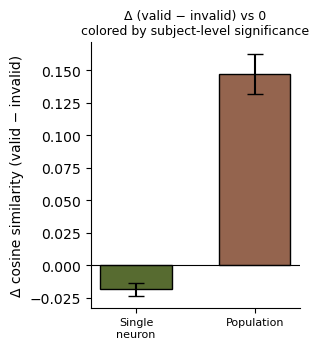

In [22]:
def delta_stat(df, valid_col="session_valid_mean", invalid_col="session_invalid_mean",
               bird_col="bird", min_birds=3):
    d = df.dropna(subset=[valid_col, invalid_col]).copy()
    d["delta"] = d[valid_col] - d[invalid_col]
    bird_delta = d.groupby(bird_col)["delta"].mean()
    n = int(len(bird_delta))
    out = dict(estimable=False, beta=np.nan, se=np.nan, p=np.nan,
               ci_lo=np.nan, ci_hi=np.nan, p_wilcoxon=np.nan,
               n_birds=n, n_sessions=int(len(d)),
               n_pos=int((bird_delta > 0).sum()))
    if n < min_birds:
        return out
    x = bird_delta.to_numpy(float)
    mean = float(x.mean()); se = float(x.std(ddof=1) / np.sqrt(n))
    p_t = float(stats.ttest_1samp(x, 0.0).pvalue)
    try:
        p_w = float(stats.wilcoxon(x).pvalue)
    except ValueError:
        p_w = np.nan
    tcrit = float(stats.t.ppf(0.975, n - 1))
    out.update(estimable=True, beta=mean, se=se, p=p_t, p_wilcoxon=p_w,
               ci_lo=mean - tcrit * se, ci_hi=mean + tcrit * se)
    return out

DELTA_RESULTS = {"single_neuron": delta_stat(df_sn_lme),
                 "population":    delta_stat(df_pop_lme)}
for k, r in DELTA_RESULTS.items():
    if r["estimable"]:
        print("%-13s  delta(valid-invalid) vs 0:  mean=%+.4f  [%+.4f, %+.4f]  "
              "t P=%.3g  Wilcoxon P=%.3g  (%d/%d birds +)"
              % (k, r["beta"], r["ci_lo"], r["ci_hi"], r["p"], r["p_wilcoxon"],
                 r["n_pos"], r["n_birds"]))
    else:
        print("%-13s  delta vs 0: not estimable (%d birds)" % (k, r["n_birds"]))

rng = np.random.default_rng(1)
fig, axd = plt.subplots(figsize=(3.2, 3.6))
for xi, (key, df) in enumerate([("single_neuron", df_sn_lme), ("population", df_pop_lme)]):
    r = DELTA_RESULTS[key]
    bm = _bird_means(df); bm["delta"] = bm["valid"] - bm["invalid"]
    md_, se_ = bm["delta"].mean(), bm["delta"].std(ddof=1) / np.sqrt(len(bm))
    axd.bar(xi, md_, yerr=se_, capsize=6, color=_sig_color(r), edgecolor="k", width=0.6)
    lbl = ("t P=%.2g" % r["p"]) if r["estimable"] else "n=%d (n.t.)" % r["n_birds"]
axd.axhline(0, color="k", lw=.8)
axd.set_xticks([0, 1]); axd.set_xticklabels(["Single\nneuron", "Population"], fontsize=8)
axd.set_ylabel("Δ cosine similarity (valid − invalid)")
axd.set_title("Δ (valid − invalid) vs 0\ncolored by subject-level significance", fontsize=9)
for sp in ("top", "right"):
    axd.spines[sp].set_visible(False)
plt.tight_layout()

## 3) Single neuron and population summary by region (All, NCM, CMM, Field L)
Split by region. CMM and Field L have only 2 birds, so they are not testable at the subject level (greyed in the figure; descriptive beta still shown).

region    | POPULATION (subject LME)                     | SINGLE-NEURON (subject LME)                 
------------------------------------------------------------------------------------------------
ALL       | b=+0.1502 P=1.51e-55 (6 birds,185 sess,-9)   | b=-0.0200 P=0.00114 (5 birds,182 sess,-12)  
NCM       | b=+0.1803 P=5.06e-10 (3 birds,111 sess,-13)  | b=-0.0270 P=0.00122 (3 birds,122 sess,-2)   
CMM       | b=+0.1065 n=2 birds NOT TESTABLE (-7)        | b=-0.0141 n=2 birds NOT TESTABLE (-0)       
Field L   | b=+0.1702 n=2 birds NOT TESTABLE (-0)        | b=-0.0113 n=1 birds NOT TESTABLE (-2)       

saved to: /mnt/cube/jugorman/EDNpopdyn/for_github/figures/ALL_cosine_by_region_grid_removeOUTLIERS_only.svg


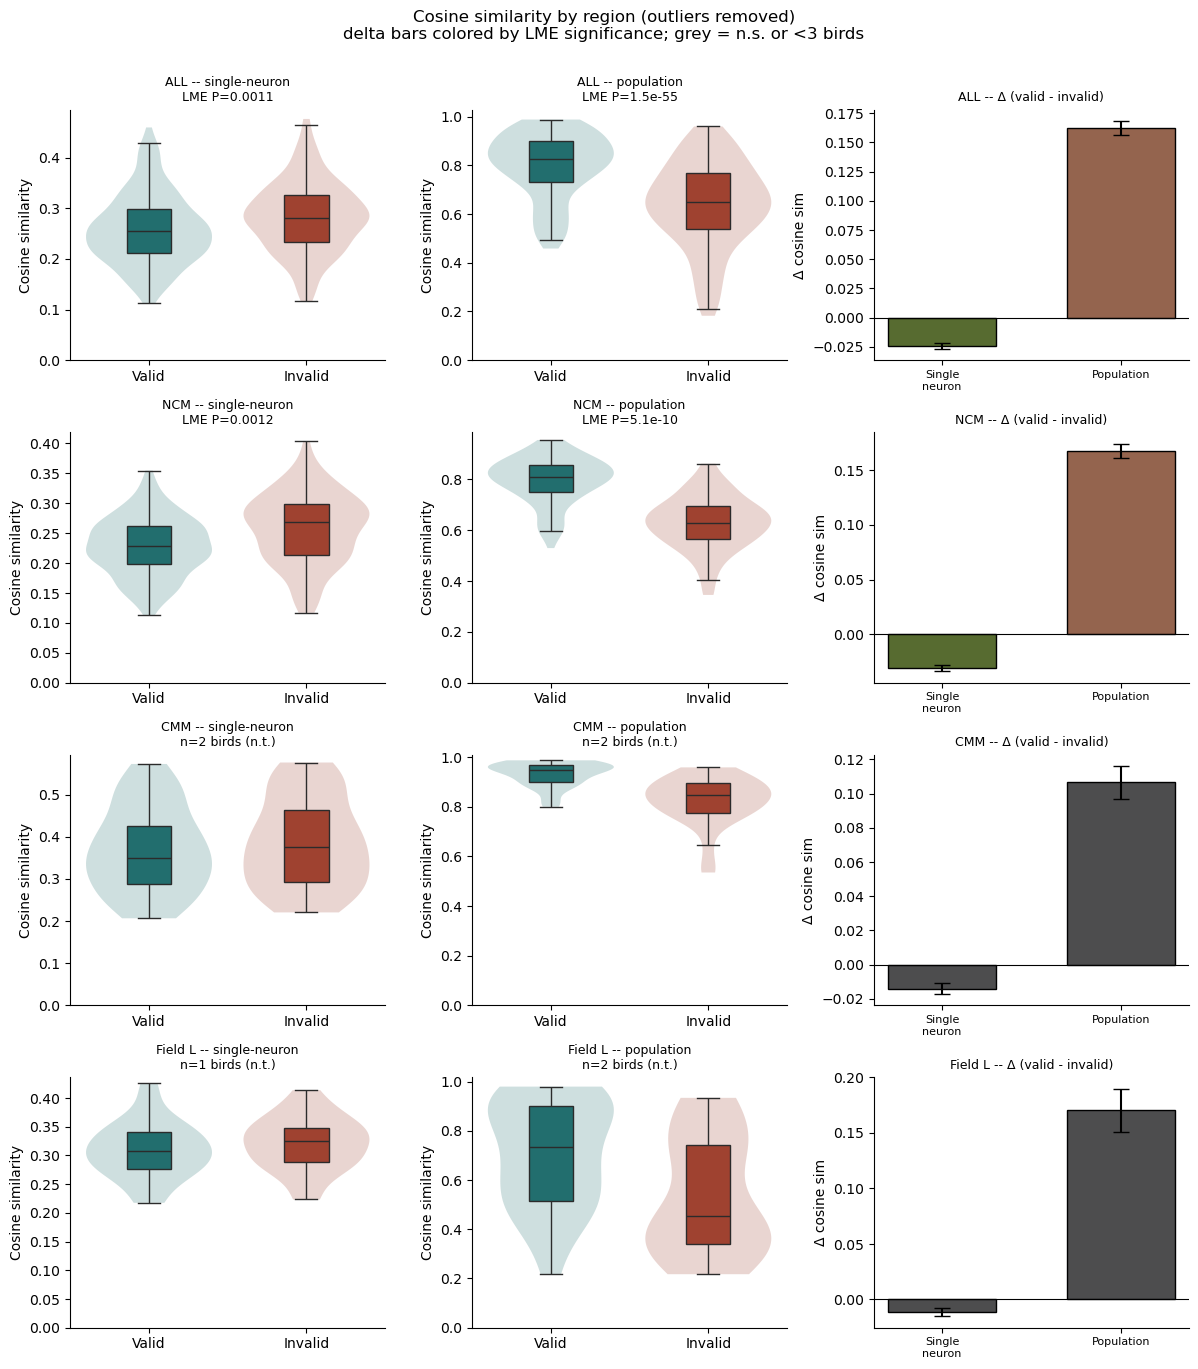

In [23]:
IQR_K        = 1.5
OUTLIER_COLS = ("session_valid_mean", "session_invalid_mean")
SIG_ALPHA_   = globals().get("SIG_ALPHA", 0.05)
COLOR_POS_   = globals().get("COLOR_POS", pal.delta_pos_fallback)
COLOR_NEG_   = globals().get("COLOR_NEG", pal.delta_neg_fallback)
COLOR_NS_    = globals().get("COLOR_NS", pal.delta_ns_fallback)
REGIONS      = ["ALL", "NCM", "CMM", "Field L"]


def _drop_outliers(df, cols=OUTLIER_COLS, k=IQR_K):
    d = df.dropna(subset=list(cols)).copy()
    keep = pd.Series(True, index=d.index)
    for c in cols:
        q1, q3 = d[c].quantile(.25), d[c].quantile(.75)
        iqr = q3 - q1
        keep &= d[c].between(q1 - k * iqr, q3 + k * iqr)
    return d[keep], int((~keep).sum())


def _sig_color(r):
    if r is None or not r.get("estimable") or not np.isfinite(r.get("p", np.nan)) or r["p"] >= SIG_ALPHA_:
        return COLOR_NS_
    return COLOR_POS_ if r["beta"] > 0 else COLOR_NEG_


def _box(ax, df, title, r):
    d = df.dropna(subset=list(OUTLIER_COLS))
    if d.empty:
        ax.text(.5, .5, "no data", transform=ax.transAxes, ha="center")
        ax.set_title(title, fontsize=9); ax.axis("off"); return
    sv, si = d["session_valid_mean"].values, d["session_invalid_mean"].values
    pdf = pd.DataFrame({"Condition": ["Valid"] * len(sv) + ["Invalid"] * len(si),
                        "Cosine similarity": np.concatenate([sv, si])})
    _n0 = len(ax.collections)
    sns.violinplot(data=pdf, x="Condition", y="Cosine similarity", order=["Valid", "Invalid"],
                   palette={"Valid": VALID_C, "Invalid": INVALID_C}, inner=None, cut=0,
                   linewidth=0, ax=ax)
    for coll in ax.collections[_n0:]:
        coll.set_alpha(0.22); coll.set_edgecolor("none"); coll.set_zorder(0)
    sns.boxplot(data=pdf, x="Condition", y="Cosine similarity", order=["Valid", "Invalid"],
                palette={"Valid": VALID_C, "Invalid": INVALID_C}, showfliers=False,
                width=0.28, ax=ax, boxprops=dict(zorder=2))
    ax.set_title("%s\n%s" % (title, _ptext(r)), fontsize=9)
    ax.set_xlabel(""); ax.set_ylim(bottom=0)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)


# ---- fit per-region LMEs (outliers removed) and print the table ----
RESULTS_RO = {}
print("=" * 96)
print("%-9s | %-44s | %-44s" % ("region", "POPULATION (subject LME)", "SINGLE-NEURON (subject LME)"))
print("-" * 96)
for reg in REGIONS:
    pdf, n_p = _drop_outliers(_sub(df_pop_lme, reg))
    sdf, n_s = _drop_outliers(_sub(df_sn_lme, reg))
    rp = subject_lme(pdf, "%s pop" % reg, verbose=False)
    rs = subject_lme(sdf, "%s sn" % reg, verbose=False)
    RESULTS_RO[reg] = dict(pop=rp, sn=rs, pop_df=pdf, sn_df=sdf, n_drop_pop=n_p, n_drop_sn=n_s)

    def _fmt(r, nd):
        if r["estimable"]:
            return "b=%+.4f P=%.3g (%d birds,%d sess,-%d)" % (r["beta"], r["p"], r["n_birds"], r["n_sessions"], nd)
        return "b=%+.4f n=%d birds NOT TESTABLE (-%d)" % (r["beta"], r["n_birds"], nd)
    print("%-9s | %-44s | %-44s" % (reg, _fmt(rp, n_p), _fmt(rs, n_s)))
print("=" * 96)

# ---- figure: [single-neuron box | population box | delta bars] per region ----
fig, axes = plt.subplots(len(REGIONS), 3, figsize=(12, 3.4 * len(REGIONS)))
fig.suptitle("Cosine similarity by region (outliers removed)\n"
             "delta bars colored by LME significance; grey = n.s. or <3 birds", y=1.003, fontsize=12)
for row, reg in enumerate(REGIONS):
    res = RESULTS_RO[reg]; ax0, ax1, ax2 = axes[row]
    _box(ax0, res["sn_df"], "%s -- single-neuron" % reg, res["sn"])
    _box(ax1, res["pop_df"], "%s -- population" % reg, res["pop"])
    for xi, (scale, df) in enumerate([("sn", res["sn_df"]), ("pop", res["pop_df"])]):
        r = res[scale]
        delta = (df["session_valid_mean"] - df["session_invalid_mean"]).dropna()
        if delta.empty: continue
        se = delta.std(ddof=1) / np.sqrt(len(delta)) if len(delta) > 1 else 0.0
        ax2.bar(xi, delta.mean(), yerr=se, capsize=6, color=_sig_color(r), edgecolor="k", width=0.6)
    ax2.axhline(0, color="k", lw=.8); ax2.set_xticks([0, 1])
    ax2.set_xticklabels(["Single\nneuron", "Population"], fontsize=8)
    ax2.set_ylabel(u"Δ cosine sim"); ax2.set_title("%s -- Δ (valid - invalid)" % reg, fontsize=9)
    for sp in ("top", "right"): ax2.spines[sp].set_visible(False)
plt.tight_layout()
_svg = os.path.join(OUT_DIR, "%s_cosine_by_region_grid_removeOUTLIERS_only.svg" % AREA)
fig.savefig(_svg, dpi=300, bbox_inches="tight")
fig.savefig(_svg.replace(".svg", ".png"), dpi=150, bbox_inches="tight")
print("\nsaved to:", _svg)
plt.show()

## 4) Passive trials: single-neuron + population
Same analysis but restricted to trials whose condition key ends in `_passive`. 

In [24]:
_keep = set(df_pop_lme["session"])
df_pop_passive = add_site_region(
    build_population_df(all_trial_dicts, modality="passive")
    .pipe(lambda d: d[d["session"].isin(_keep)])
    .dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())
print("population passive   : %d sessions, %d birds"
      % (df_pop_passive["session"].nunique(), df_pop_passive["bird"].nunique()))
df_sn_passive = add_site_region(
    build_single_neuron_df(neural_trial_dicts, modality="passive")
    .pipe(lambda d: d[d["session"].isin(_keep)])
    .dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())
print("single-neuron passive: %d sessions, %d birds"
      % (df_sn_passive["session"].nunique(), df_sn_passive["bird"].nunique()))

population passive   : 88 sessions, 5 birds
single-neuron passive: 88 sessions, 5 birds


PASSIVE outliers removed -- single-neuron: -1 sessions | population: -9 sessions
saved to: /mnt/cube/jugorman/EDNpopdyn/for_github/figures/ALL_passive_cosine_violinbox_removeOUTLIERS_only.svg


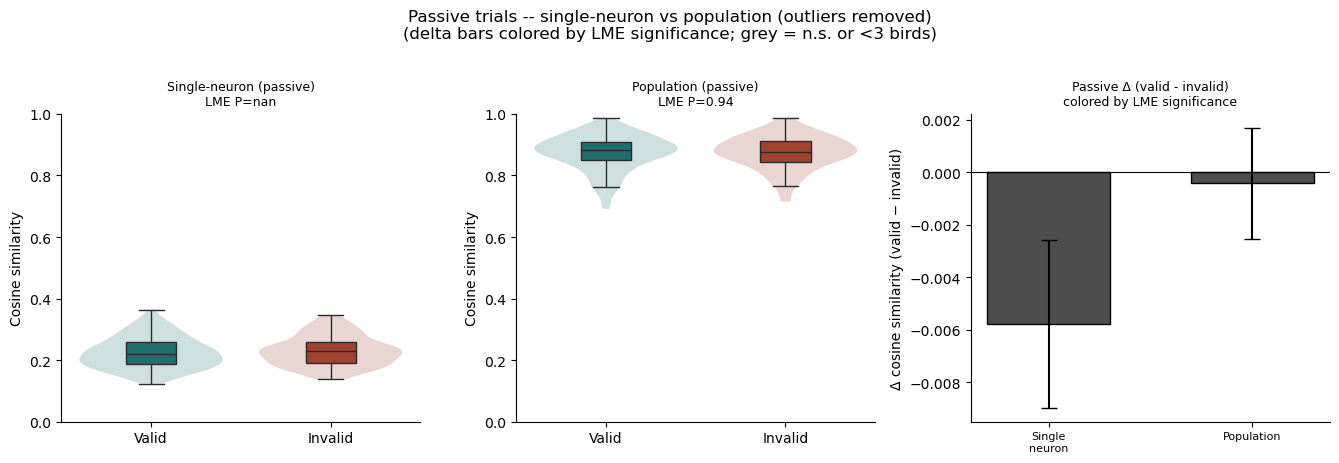

In [25]:
IQR_K        = 1.5
OUT_COLS     = ("session_valid_mean", "session_invalid_mean")
SIG_ALPHA_   = globals().get("SIG_ALPHA", 0.05)
COLOR_POS_   = globals().get("COLOR_POS", pal.delta_pos_fallback)
COLOR_NEG_   = globals().get("COLOR_NEG", pal.delta_neg_fallback)
COLOR_NS_    = globals().get("COLOR_NS", pal.delta_ns_fallback)


def _drop_outliers(df, cols=OUT_COLS, k=IQR_K):
    d = df.dropna(subset=list(cols)).copy()
    keep = pd.Series(True, index=d.index)
    for c in cols:
        q1, q3 = d[c].quantile(.25), d[c].quantile(.75)
        iqr = q3 - q1
        keep &= d[c].between(q1 - k * iqr, q3 + k * iqr)
    return d[keep], int((~keep).sum())


def _sig_color(r):
    if r is None or not r.get("estimable") or not np.isfinite(r.get("p", np.nan)) or r["p"] >= SIG_ALPHA_:
        return COLOR_NS_
    return COLOR_POS_ if r["beta"] > 0 else COLOR_NEG_


def _box(ax, df, title, r):
    d = df.dropna(subset=list(OUT_COLS))
    if d.empty:
        ax.text(.5, .5, "no passive data", transform=ax.transAxes, ha="center")
        ax.set_title(title, fontsize=9); ax.axis("off"); return
    sv, si = d["session_valid_mean"].values, d["session_invalid_mean"].values
    pdf = pd.DataFrame({"Condition": ["Valid"] * len(sv) + ["Invalid"] * len(si),
                        "Cosine similarity": np.concatenate([sv, si])})
    _n0 = len(ax.collections)
    sns.violinplot(data=pdf, x="Condition", y="Cosine similarity", order=["Valid", "Invalid"],
                   palette={"Valid": VALID_C, "Invalid": INVALID_C}, inner=None, cut=0,
                   linewidth=0, ax=ax)
    for coll in ax.collections[_n0:]:
        coll.set_alpha(0.22); coll.set_edgecolor("none"); coll.set_zorder(0)
    sns.boxplot(data=pdf, x="Condition", y="Cosine similarity", order=["Valid", "Invalid"],
                palette={"Valid": VALID_C, "Invalid": INVALID_C}, showfliers=False,
                width=0.28, ax=ax, boxprops=dict(zorder=2))
    ax.set_title("%s\n%s" % (title, _ptext(r)), fontsize=9)
    ax.set_xlabel(""); ax.set_ylim(bottom=0)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)


sn_f,  n_drop_sn  = _drop_outliers(df_sn_passive)
pop_f, n_drop_pop = _drop_outliers(df_pop_passive)
res_sn  = subject_lme(sn_f,  "passive sn (RO)",  verbose=False)
res_pop = subject_lme(pop_f, "passive pop (RO)", verbose=False)
print("PASSIVE outliers removed -- single-neuron: -%d sessions | population: -%d sessions"
      % (n_drop_sn, n_drop_pop))

fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.5))
fig.suptitle("Passive trials -- single-neuron vs population (outliers removed)\n"
             "(delta bars colored by LME significance; grey = n.s. or <3 birds)", y=1.02, fontsize=12)
_box(ax[0], sn_f,  "Single-neuron (passive)", res_sn)
_box(ax[1], pop_f, "Population (passive)",    res_pop)
ytop = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])
ax[0].set_ylim(0, ytop)
ax[1].set_ylim(0, ytop)
for xi, (r, df) in enumerate([(res_sn, sn_f), (res_pop, pop_f)]):
    delta = (df["session_valid_mean"] - df["session_invalid_mean"]).dropna()
    if delta.empty: continue
    se = delta.std(ddof=1) / np.sqrt(len(delta)) if len(delta) > 1 else 0.0
    ax[2].bar(xi, delta.mean(), yerr=se, capsize=6, color=_sig_color(r), edgecolor="k", width=0.6)
ax[2].axhline(0, color="k", lw=.8); ax[2].set_xticks([0, 1])
ax[2].set_xticklabels(["Single\nneuron", "Population"], fontsize=8)
ax[2].set_ylabel(u"Δ cosine similarity (valid − invalid)")
ax[2].set_title("Passive Δ (valid - invalid)\ncolored by LME significance", fontsize=9)
for sp in ("top", "right"): ax[2].spines[sp].set_visible(False)
plt.tight_layout()
_svg = os.path.join(OUT_DIR, "%s_passive_cosine_violinbox_removeOUTLIERS_only.svg" % AREA)
fig.savefig(_svg, dpi=300, bbox_inches="tight")
fig.savefig(_svg.replace(".svg", ".png"), dpi=150, bbox_inches="tight")
print("saved to:", _svg); plt.show()

saved to: /mnt/cube/jugorman/EDNpopdyn/for_github/figures/ALL_delta_active_vs_passive.svg


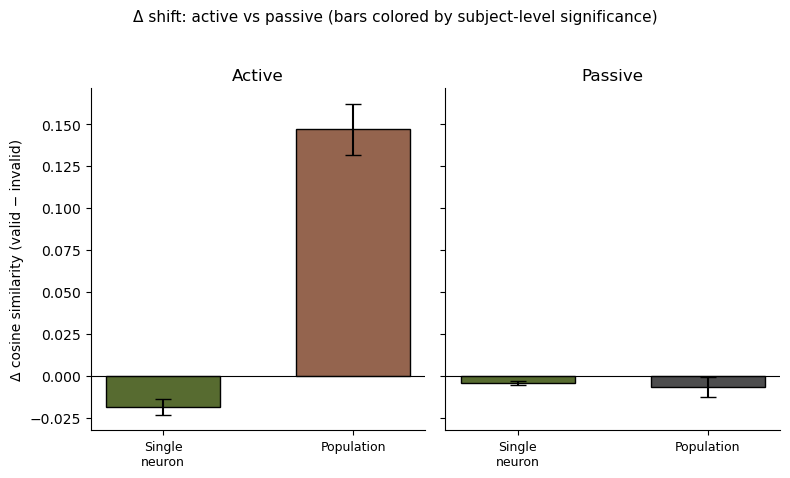

In [26]:
#COMBIEND DELTA BAR PLOT

COLOR_POS = globals().get("COLOR_POS", "darkcyan")
COLOR_NEG = globals().get("COLOR_NEG", pal.invalid_fallback)
COLOR_NS  = globals().get("COLOR_NS", "0.6")
SIG_ALPHA = globals().get("SIG_ALPHA", 0.05)
DOT       = globals().get("DOT", 45)

def _bird_deltas(df):
    bm = (df.dropna(subset=["session_valid_mean", "session_invalid_mean"])
            .groupby("bird")[["session_valid_mean", "session_invalid_mean"]].mean())
    return (bm["session_valid_mean"] - bm["session_invalid_mean"]).to_numpy(float)

def _delta_stat(df):
    d = _bird_deltas(df); n = len(d)
    out = dict(estimable=False, beta=np.nan, p=np.nan, n_birds=n)
    if n >= 3:
        out.update(estimable=True, beta=float(d.mean()),
                   p=float(stats.ttest_1samp(d, 0.0).pvalue))
    return out

def _sig_color(r):
    if (not r.get("estimable")) or (not np.isfinite(r.get("p", np.nan))) or r["p"] >= SIG_ALPHA:
        return COLOR_NS
    return COLOR_POS if r["beta"] > 0 else COLOR_NEG

PANELS = [("Active",  df_sn_lme,     df_pop_lme),
          ("Passive", df_sn_passive, df_pop_passive)]

fig, axes = plt.subplots(1, 2, figsize=(8, 4.6), sharey=True)
rng = np.random.default_rng(1)
for ax, (cond, df_sn, df_pop) in zip(axes, PANELS):
    for xi, (lbl, df) in enumerate([("Single\nneuron", df_sn), ("Population", df_pop)]):
        d = _bird_deltas(df)
        if len(d) == 0:
            continue
        r = _delta_stat(df)
        m = float(d.mean())
        se = float(d.std(ddof=1) / np.sqrt(len(d))) if len(d) > 1 else 0.0
        ax.bar(xi, m, yerr=se, capsize=6, color=_sig_color(r), edgecolor="k", width=0.6)
    ax.axhline(0, color="k", lw=.8)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Single\nneuron", "Population"], fontsize=9)
    ax.set_title(cond, fontsize=12)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

axes[0].set_ylabel("Δ cosine similarity (valid − invalid)")
fig.suptitle("Δ shift: active vs passive (bars colored by subject-level significance)",
             y=1.03, fontsize=11)
fig.tight_layout()

_svg = os.path.join(OUT_DIR, "%s_delta_active_vs_passive.svg" % AREA)
fig.savefig(_svg, dpi=300, bbox_inches="tight")
fig.savefig(_svg.replace(".svg", ".png"), dpi=200, bbox_inches="tight")
print("saved to:", _svg)
plt.show()